In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Dataset/OnlineRetail.csv", encoding="latin-1")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.duplicated().sum()

5268

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.dropna(subset=["CustomerID"],inplace=True)

In [9]:
df.drop(columns="Description",inplace=True)

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]

In [12]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['CustomerID']=df['CustomerID'].astype(int)

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [14]:
df['TotalAmount']=df['Quantity']*df['UnitPrice']

In [15]:
monetary=df.groupby('CustomerID')['TotalAmount'].sum()

In [16]:
frequency=df.groupby('CustomerID')['InvoiceNo'].nunique()

In [17]:
ref_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
recency=(ref_date-df.groupby('CustomerID')['InvoiceDate'].max()).dt.days

In [18]:
rfm=pd.DataFrame({'Recency':recency, 'Frequency':frequency, 'Monetary': monetary})

In [19]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [20]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


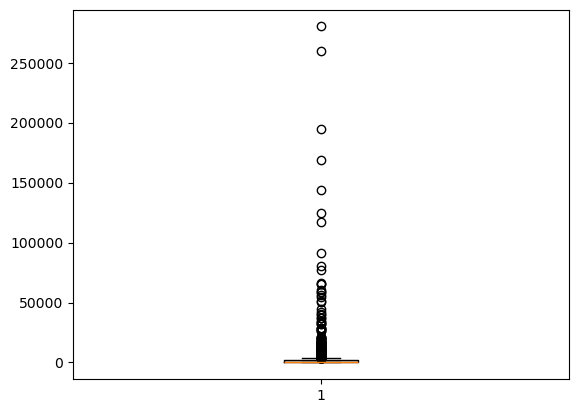

In [21]:
plt.boxplot(rfm["Monetary"])
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.334574,-0.425097,8.363010
12347,-0.905340,0.354417,0.251699
12348,-0.175360,-0.035340,-0.027988
12349,-0.735345,-0.425097,-0.032406
12350,2.174578,-0.425097,-0.190812


In [24]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)

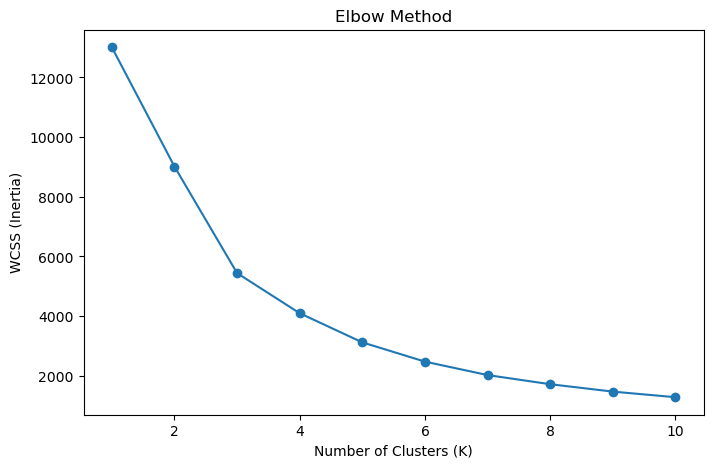

In [25]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.show()

In [26]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [27]:
rfm["Cluster"].value_counts()

Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64

In [28]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_summary)

            Recency  Frequency      Monetary
Cluster                                     
0        247.106285   1.582255    629.663689
1         41.454180   4.672755   1849.670202
2          6.038462  66.423077  85826.078077


In [29]:
cluster_names = {
    0: "Inactive",
    1: "Regular",
    2: "VIP"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

In [30]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer Segment
CustomerID,,,,,
12346,326,1,77183.60,0,Inactive
12347,2,7,4310.00,1,Regular
12348,75,4,1797.24,1,Regular
12349,19,1,1757.55,1,Regular
12350,310,1,334.40,0,Inactive


<Axes: xlabel='Customer Segment'>

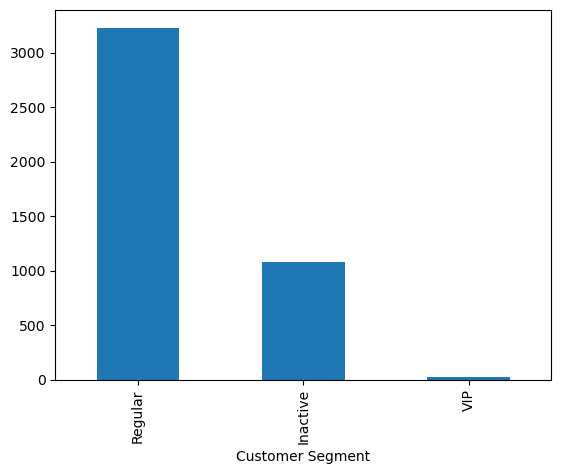

In [31]:
rfm["Customer Segment"].value_counts().plot(kind="bar"

<Axes: xlabel='Customer Segment'>

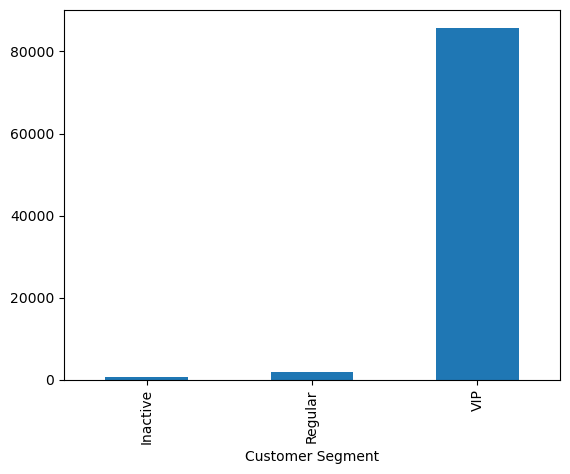

In [32]:
rfm.groupby("Customer Segment")["Monetary"].mean().plot(kind="bar")

<Axes: xlabel='Customer Segment'>

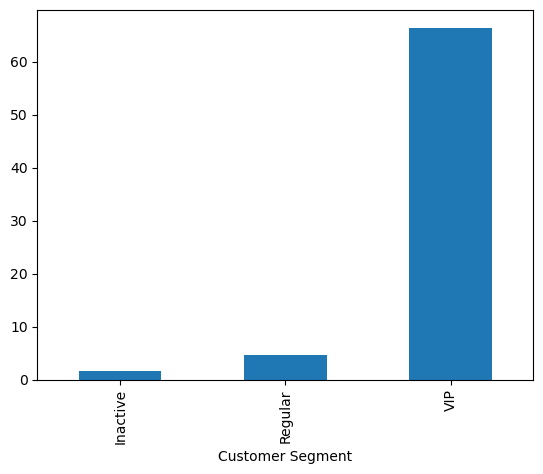

In [33]:
rfm.groupby("Customer Segment")["Frequency"].mean().plot(kind="bar")

<Axes: xlabel='Customer Segment'>

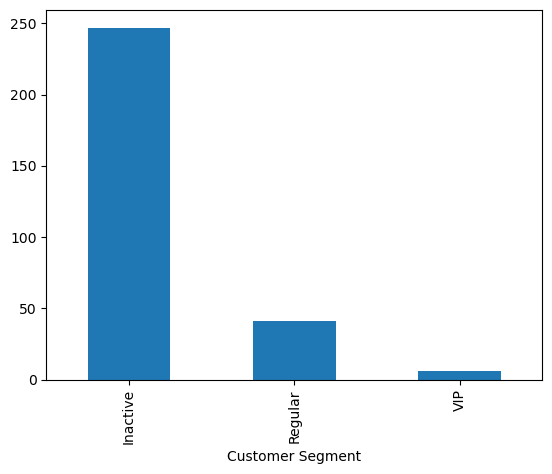

In [34]:
rfm.groupby("Customer Segment")["Recency"].mean().plot(kind="bar")

# Insighs
- Regular customers account for nearly 75% of the customer base, making them the primary revenue-driving segment.
- VIP customers represent less than 1% of customers (26 customers) but have exceptionally high purchase frequency and spending, indicating a high-value segment.
- Inactive customers have not purchased for approximately 247 days on average and may benefit from targeted re-engagement campaigns.
- VIP customers purchased very recently (around 6 days on average), suggesting strong loyalty and consistent engagement.
- Customer segmentation using K-Means enables businesses to personalize marketing strategies instead of treating all customers the same.